# Agreement of LLM Judges in Persona Contradiction Detection

**Author:** Matyáš Martinek
**Course:** Probability and Statistics
**Language:** Python

## 1. Motivation and research questions

Large language models are increasingly used as automatic evaluators, or
*LLM judges*, when manual annotation would be expensive. My bachelor's thesis
focuses on persona consistency in dialogue, where a model should remain
consistent with a predefined persona throughout a conversation.

One possible way to evaluate persona consistency automatically is to give a
persona and its dialogue to another language model and ask whether they contain
a contradiction. Before relying on such judgments, however, it is useful to
know whether different LLM judges actually make similar decisions.

The main research question of this project is therefore:

> **Do different LLM judges agree when detecting persona contradictions?**

The analysis focuses on three related questions:

1. **Inter-judge agreement:** How strongly do different LLM judges agree on
   the same persona–dialogue examples, and do some judges label contradictions
   substantially more often than others?

2. **Input characteristics:** Is judge behaviour related to properties of the
   evaluated input, such as its length or the type of contradiction-oriented
   augmentation?

3. **Prompt robustness:** Does an individual judge make similar decisions when
   the same examples are evaluated using a slightly different formulation of
   the judging prompt?

In addition, the paired structure of the data makes it possible to investigate
whether contradiction-oriented persona augmentation systematically increases
the number of judges that identify a contradiction.

### Statistical questions

For differences between judges, the confirmatory null hypothesis is

\[
H_0:
\text{the LLM judges have the same tendency to label examples as contradictory,}
\]

against

\[
H_1:
\text{at least one judge has a different contradiction tendency.}
\]

Inter-judge agreement itself is described using raw agreement and Cohen's
kappa. A permutation test is then used to test whether the observed
differences in contradiction rates between judges are larger than would be
expected if judge identities were interchangeable.

For the effect of persona augmentation, the paired original and augmented
versions of the same dialogue are compared. The corresponding null hypothesis
is that, within a pair, the labels *original* and *augmented* are
interchangeable. A paired permutation test is used for hypothesis testing and
a bootstrap confidence interval is used to quantify the size and uncertainty
of the augmentation effect.

The analysis uses a significance level of

\[
\alpha = 0.05.
\]

## 2. Data and experimental design

### 2.1 PersonaChat and derived data

The experiment is based on the **PersonaChat** dataset introduced by
Zhang et al. (2018). PersonaChat contains multi-turn English dialogues in
which each participant is assigned a persona represented by several natural
language statements.

The dataset is available through Hugging Face:

https://huggingface.co/datasets/awsaf49/persona-chat

The original dataset is described in:

> Zhang, S., Dinan, E., Urbanek, J., Szlam, A., Kiela, D., & Weston, J.
> (2018). *Personalizing Dialogue Agents: I have a dog, do you have pets too?*
> Proceedings of ACL 2018, pp. 2204–2213.
> https://aclanthology.org/P18-1205/

For this statistical project I use a dataset derived from PersonaChat as part
of my bachelor's thesis on persona consistency:

`data/personachat_augmented_v2.parquet`

The derived dataset contains complete speaker personas paired with their
dialogues. Persona facts were automatically grounded in the dialogue and
contradiction-oriented persona variants were generated using deterministic
rule-based augmentations.

Examples of the applied augmentation rules include preference negation,
changes of age or profession, changes in family composition, and replacement
of favorite items.

Each profile contains, among other metadata:

- the complete original persona,
- the complete augmented persona,
- the unchanged dialogue,
- the types and number of applied augmentations,
- grounding information for changed persona facts.

An augmented rule-based profile receives the expected relation
`contradiction` when at least one changed persona fact is grounded in the
dialogue. These automatically derived relations are used to construct the
experiment, but they are **not treated as manually verified ground-truth
labels**.

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd


RANDOM_SEED = 42
N_PAIRS = 1000

DATA_DIR = Path("data")

SOURCE_DATA_PATH = (
    DATA_DIR
    / "personachat_augmented_v2.parquet"
)

EXPERIMENT_DATA_PATH = (
    DATA_DIR
    / "llm_judge_experiment_v2.parquet"
)


source_df = pd.read_parquet(
    SOURCE_DATA_PATH
)

print(
    f"Loaded {len(source_df):,} "
    f"derived PersonaChat profiles."
)

Loaded 26,368 derived PersonaChat profiles.


In [2]:
source_summary = pd.DataFrame(
    {
        "value": [
            len(source_df),
            source_df["dialogue_id"].nunique(),
            source_df[
                "augmentation_family"
            ].eq("rule").sum(),
            source_df[
                "augmentation_family"
            ].eq("persona_swap").sum(),
        ],
    },
    index=[
        "profiles",
        "unique_dialogues",
        "rule_based_profiles",
        "persona_swap_profiles",
    ],
)

source_summary

,value
profiles,26368
unique_dialogues,8939
rule_based_profiles,8490
persona_swap_profiles,17878


### 2.2 Construction of the experimental sample

The statistical experiment uses only rule-based augmented profiles for which
the augmentation pipeline assigned the expected relation `contradiction` and
at least one changed persona fact was grounded in the dialogue.

Persona-swap examples are excluded because they represent a different
augmentation mechanism and are currently treated as contradiction candidates
rather than the rule-based contradiction-oriented profiles studied here.

For every selected profile, two matched evaluation examples are constructed:

1. **Original variant:** the complete original persona together with the
   original dialogue.
2. **Augmented variant:** the complete augmented persona together with exactly
   the same dialogue.

The only intended difference within a pair is therefore the persona
modification introduced by the augmentation.

Eligible profiles are randomly shuffled using a fixed seed. To avoid
evaluating multiple speaker profiles from the same conversation, only the
first retained profile for each dialogue is kept. The first 1,000 unique
dialogues from this deterministic sampling procedure form the experimental
sample.

The sample is created before inspecting the outputs of any LLM judge and is
kept fixed for all subsequent evaluation.

In [3]:
eligible_df = source_df[
    source_df[
        "augmentation_family"
    ].eq("rule")
    & source_df[
        "expected_relation"
    ].eq("contradiction")
    & source_df[
        "num_grounded_augmented_facts"
    ].gt(0)
].copy()


sampling_pool = (
    eligible_df
    .sample(
        frac=1,
        random_state=RANDOM_SEED,
    )
    .drop_duplicates(
        subset="dialogue_id"
    )
    .reset_index(drop=True)
)


if len(sampling_pool) < N_PAIRS:
    raise ValueError(
        f"Only {len(sampling_pool):,} "
        f"unique eligible dialogues are available, "
        f"but {N_PAIRS:,} were requested."
    )


selected_pairs_df = (
    sampling_pool
    .head(N_PAIRS)
    .copy()
    .reset_index(drop=True)
)


selected_pairs_df = (
    selected_pairs_df.rename(
        columns={
            "num_augmented_facts":
                "pair_num_augmented_facts",
            "num_grounded_augmented_facts":
                "pair_num_grounded_augmented_facts",
        }
    )
)

In [4]:
selection_summary = pd.DataFrame(
    {
        "value": [
            len(eligible_df),
            eligible_df[
                "dialogue_id"
            ].nunique(),
            len(sampling_pool),
            len(selected_pairs_df),
            selected_pairs_df[
                "dialogue_id"
            ].nunique(),
        ],
    },
    index=[
        "eligible_profiles",
        "eligible_unique_dialogues",
        "sampling_pool_unique_dialogues",
        "selected_profiles",
        "selected_unique_dialogues",
    ],
)

selection_summary

,value
eligible_profiles,8469
eligible_unique_dialogues,6399
sampling_pool_unique_dialogues,6399
selected_profiles,1000
selected_unique_dialogues,1000


In [5]:
def format_persona(
    persona,
) -> str:
    """Format persona facts for LLM evaluation."""
    return "\n".join(
        f"- {fact}"
        for fact in persona
    )


pair_ids = [
    f"pair_{i:04d}"
    for i in range(
        len(selected_pairs_df)
    )
]


original_df = selected_pairs_df.copy()

original_df["pair_id"] = pair_ids
original_df["variant"] = "original"

original_df["persona_text"] = (
    original_df[
        "original_persona"
    ].map(format_persona)
)

original_df["expected_label"] = (
    "NO_CONTRADICTION"
)

original_df[
    "expected_label_binary"
] = 0


augmented_df = selected_pairs_df.copy()

augmented_df["pair_id"] = pair_ids
augmented_df["variant"] = "augmented"

augmented_df["persona_text"] = (
    augmented_df[
        "augmented_persona"
    ].map(format_persona)
)

augmented_df["expected_label"] = (
    "CONTRADICTION"
)

augmented_df[
    "expected_label_binary"
] = 1


experiment_df = pd.concat(
    [
        original_df,
        augmented_df,
    ],
    ignore_index=True,
)


experiment_df["example_id"] = (
    experiment_df["pair_id"]
    + "_"
    + experiment_df["variant"]
)


experiment_df["num_changed_facts"] = (
    experiment_df[
        "variant"
    ]
    .eq("augmented")
    .astype(int)
    * experiment_df[
        "pair_num_augmented_facts"
    ]
)


experiment_df[
    "num_grounded_changed_facts"
] = (
    experiment_df[
        "variant"
    ]
    .eq("augmented")
    .astype(int)
    * experiment_df[
        "pair_num_grounded_augmented_facts"
    ]
)


experiment_df = (
    experiment_df
    .sample(
        frac=1,
        random_state=RANDOM_SEED,
    )
    .reset_index(drop=True)
)

In [6]:
assert len(
    experiment_df
) == 2 * N_PAIRS

assert (
    experiment_df[
        "example_id"
    ].is_unique
)

assert (
    experiment_df[
        "pair_id"
    ].nunique()
    == N_PAIRS
)

assert (
    experiment_df[
        "dialogue_id"
    ].nunique()
    == N_PAIRS
)

assert (
    experiment_df
    .groupby(
        "pair_id"
    )
    .size()
    .eq(2)
    .all()
)

assert (
    experiment_df
    .groupby(
        "pair_id"
    )[
        "variant"
    ]
    .nunique()
    .eq(2)
    .all()
)

assert (
    experiment_df
    .groupby(
        "pair_id"
    )[
        "dialogue_text"
    ]
    .nunique()
    .eq(1)
    .all()
)

assert (
    experiment_df[
        "variant"
    ]
    .value_counts()
    .to_dict()
    == {
        "original": 1000,
        "augmented": 1000,
    }
)

print(
    "Experimental sample validation passed."
)

Experimental sample validation passed.


In [7]:
experiment_summary = pd.DataFrame(
    {
        "count": [
            len(experiment_df),
            experiment_df[
                "pair_id"
            ].nunique(),
            experiment_df[
                "dialogue_id"
            ].nunique(),
            experiment_df[
                "variant"
            ].eq(
                "original"
            ).sum(),
            experiment_df[
                "variant"
            ].eq(
                "augmented"
            ).sum(),
        ],
    },
    index=[
        "examples",
        "matched_pairs",
        "unique_dialogues",
        "original_examples",
        "augmented_examples",
    ],
)

experiment_summary

,count
examples,2000
matched_pairs,1000
unique_dialogues,1000
original_examples,1000
augmented_examples,1000


### 2.3 Input characteristics

Several simple characteristics of each persona–dialogue input are computed
before LLM evaluation.

The following variables are available for later secondary analysis:

- `persona_length` – number of word tokens in the complete persona,
- `dialogue_length` – number of word tokens in the dialogue,
- `input_length` – total persona and dialogue length,
- `lexical_overlap` – Jaccard similarity between the sets of words appearing
  in the persona and dialogue,
- `persona_fact_count` – number of persona statements.

The augmentation metadata also records which rule types were applied and how
many persona facts were changed.

The main analysis of textual characteristics will focus on input length.
Augmentation type will be examined separately as a descriptive secondary
analysis.

In [8]:
WORD_PATTERN = re.compile(
    r"[A-Za-z]+(?:'[A-Za-z]+)?"
)


def tokenize_words(
    text: str,
) -> list[str]:
    """Return lowercase English word tokens."""
    return WORD_PATTERN.findall(
        str(text).lower()
    )


def jaccard_overlap(
    text_a: str,
    text_b: str,
) -> float:
    """Compute Jaccard similarity between word sets."""
    words_a = set(
        tokenize_words(text_a)
    )

    words_b = set(
        tokenize_words(text_b)
    )

    union = (
        words_a
        | words_b
    )

    if not union:
        return 0.0

    return (
        len(
            words_a
            & words_b
        )
        / len(union)
    )

In [9]:
experiment_df[
    "persona_length"
] = (
    experiment_df[
        "persona_text"
    ]
    .map(tokenize_words)
    .map(len)
)


experiment_df[
    "dialogue_length"
] = (
    experiment_df[
        "dialogue_text"
    ]
    .map(tokenize_words)
    .map(len)
)


experiment_df[
    "input_length"
] = (
    experiment_df[
        "persona_length"
    ]
    + experiment_df[
        "dialogue_length"
    ]
)


experiment_df[
    "lexical_overlap"
] = experiment_df.apply(
    lambda row:
        jaccard_overlap(
            row["persona_text"],
            row["dialogue_text"],
        ),
    axis=1,
)

In [10]:
input_characteristics_summary = (
    experiment_df[
        [
            "persona_fact_count",
            "persona_length",
            "dialogue_length",
            "input_length",
            "lexical_overlap",
        ]
    ]
    .describe()
    .round(3)
)

input_characteristics_summary

,persona_fact_count,persona_length,dialogue_length,input_length,lexical_overlap
count,2000.000,2000.000,2000.000,2000.000,2000.000
mean,4.540,26.822,165.115,191.936,0.141
std,0.508,6.707,28.514,29.638,0.044
min,3.000,11.000,74.000,99.000,0.025
25%,4.000,22.000,146.000,172.000,0.111
50%,5.000,26.000,164.000,192.000,0.136
75%,5.000,31.000,184.000,210.000,0.165
max,5.000,67.000,329.000,352.000,0.329


### 2.4 Frozen evaluation dataset

After sample construction and computation of input characteristics, the
evaluation dataset is frozen before running the LLM judges.

The frozen dataset contains 2,000 examples corresponding to 1,000 matched
original–augmented pairs:

`data/llm_judge_experiment_v2.parquet`

All LLM judges are evaluated on exactly this same dataset. The sample is not
modified based on model predictions.

Keeping the evaluation sample separate from the model inference makes the
experiment reproducible: the dataset can be reconstructed from the derived
PersonaChat data using the code above, while the LLM evaluations can be
rerun independently using the inference script described in the next section.

In [11]:
experiment_df.to_parquet(
    EXPERIMENT_DATA_PATH,
    index=False,
)

print(
    f"Saved {len(experiment_df):,} examples "
    f"({experiment_df['pair_id'].nunique():,} pairs) "
    f"to {EXPERIMENT_DATA_PATH}"
)

Saved 2,000 examples (1,000 pairs) to data/llm_judge_experiment_v2.parquet


In [12]:
frozen_experiment_df = (
    pd.read_parquet(
        EXPERIMENT_DATA_PATH
    )
)


assert len(
    frozen_experiment_df
) == 2000

assert (
    frozen_experiment_df[
        "example_id"
    ].is_unique
)

assert (
    frozen_experiment_df[
        "pair_id"
    ].nunique()
    == 1000
)

assert (
    set(
        frozen_experiment_df[
            "example_id"
        ]
    )
    == set(
        experiment_df[
            "example_id"
        ]
    )
)


print(
    "Frozen evaluation dataset is ready."
)

Frozen evaluation dataset is ready.


## 3. LLM judges and evaluation

### 3.1 Models and evaluation prompt

The frozen experimental sample is evaluated independently by four language
models from different model families:

- `Qwen/Qwen3-4B`,
- `microsoft/Phi-4-mini-instruct`,
- `meta-llama/Llama-3.2-3B-Instruct`,
- `mistralai/Mistral-7B-Instruct-v0.3`.

Each judge receives exactly the same information:

1. the complete persona of the speaker being evaluated,
2. the complete dialogue, with utterances explicitly marked as `SELF` or
   `PARTNER`.

The task is binary. The judge must return exactly one of:

- `CONTRADICTION`,
- `NO_CONTRADICTION`.

A contradiction is defined as a statement made or clearly implied by `SELF`
that is incompatible with at least one statement in `SELF`'s persona.

Statements made only by `PARTNER` are not treated as evidence about `SELF`.
The prompt also explicitly distinguishes genuine contradictions from missing
evidence, compatible additional information, and differences caused only by
temporal or modal context.

The automatically derived expected labels described in Section 2 are **not
included in the prompt**. They remain metadata used only for secondary
analysis.

In [13]:
from judge_config import (
    PROMPT_ID,
    build_judge_prompt,
    parse_judge_output,
)


print(
    f"Evaluation prompt version: {PROMPT_ID}"
)

Evaluation prompt version: full_persona_v3


In [14]:
print(
    build_judge_prompt(
        persona=(
            "- <persona statement 1>\n"
            "- <persona statement 2>"
        ),
        dialogue=(
            "SELF: <self utterance>\n"
            "PARTNER: <partner utterance>"
        ),
    )
)

You are a binary judge of persona consistency.

Determine whether statements made by SELF in the dialogue contradict at least one statement in SELF's persona.

Rules:
- CONTRADICTION: SELF explicitly states or clearly implies information that cannot be true at the same time as at least one persona statement.
- NO_CONTRADICTION: no such conflict is present.
- One conflicting persona statement is sufficient for CONTRADICTION.
- A persona statement that is not discussed in the dialogue is not a contradiction.
- Claims made only by PARTNER are not evidence about SELF. Use PARTNER's utterances only as conversational context.
- Respect temporal and modal information. Past and present statements, intentions, wishes, and current facts are contradictions only when they are genuinely incompatible.
- Additional compatible information is not a contradiction.
- Use only the information in the persona and dialogue. Do not assume unstated facts.

Persona of SELF:
- <persona statement 1>
- <persona st

### 3.2 Reproducing the LLM evaluation

The model inference itself is not executed inside this notebook because it
requires GPU resources. Instead, the frozen dataset is evaluated using the
script

`scripts/run_llm_judge.py`.

For each model, the script:

1. obtains the current Hugging Face model revision and uses that exact revision
   for both tokenizer and model loading,
2. formats the task using the model's native chat template,
3. disables Qwen3's optional thinking mode,
4. performs deterministic generation with sampling disabled,
5. allows at most 16 newly generated tokens,
6. parses the generated text into the binary label,
7. stores the raw output together with the parsed label, prompt identifier,
   model identifier, model revision, and example identifiers.

Input truncation is disabled.

The experiments used one GPU per model run. On the AIC computing cluster the
commands below were submitted as Slurm batch jobs; the Slurm wrapper only
provides computational resources, while `run_llm_judge.py` contains the actual
evaluation procedure.

The Python packages required for the GPU runs are listed in
`requirements-aic.txt`.

The commands used for the four full evaluations are shown below. During each run, the inference script resolves and records the exact Hugging Face model revision, so the model snapshot used in the reported results is preserved as provenance in the output files.

```bash
# Qwen3-4B
python -m scripts.run_llm_judge \
  --input data/llm_judge_experiment_v2.parquet \
  --output outputs/judgments/qwen3_4b_full_v3.parquet \
  --model-name Qwen/Qwen3-4B \
  --model-id qwen3_4b \
  --batch-size 4

# Phi-4-mini-instruct
python -m scripts.run_llm_judge \
  --input data/llm_judge_experiment_v2.parquet \
  --output outputs/judgments/phi4_mini_full_v3.parquet \
  --model-name microsoft/Phi-4-mini-instruct \
  --model-id phi4_mini \
  --batch-size 4

# Llama-3.2-3B-Instruct
python -m scripts.run_llm_judge \
  --input data/llm_judge_experiment_v2.parquet \
  --output outputs/judgments/llama32_3b_full_v3.parquet \
  --model-name meta-llama/Llama-3.2-3B-Instruct \
  --model-id llama32_3b \
  --batch-size 4

# Mistral-7B-Instruct-v0.3
python -m scripts.run_llm_judge \
  --input data/llm_judge_experiment_v2.parquet \
  --output outputs/judgments/mistral7b_full_v3.parquet \
  --model-name mistralai/Mistral-7B-Instruct-v0.3 \
  --model-id mistral7b \
  --batch-size 2
```

The GPU runs save one Parquet file per judge. For the statistical analysis,
the four result files are stored locally under:

`data/outputs/`

The inference results are therefore generated separately from the notebook and
then loaded below. This avoids rerunning the language models whenever the
statistical analysis is reproduced.

In [15]:
JUDGMENTS_DIR = (
    DATA_DIR
    / "outputs"
)


JUDGE_CONFIGS = {
    "qwen3_4b": {
        "label": "Qwen3-4B",
        "model_name": "Qwen/Qwen3-4B",
        "file": "qwen3_4b_full_v3.parquet",
    },
    "phi4_mini": {
        "label": "Phi-4-mini-instruct",
        "model_name": "microsoft/Phi-4-mini-instruct",
        "file": "phi4_mini_full_v3.parquet",
    },
    "llama32_3b": {
        "label": "Llama-3.2-3B-Instruct",
        "model_name": "meta-llama/Llama-3.2-3B-Instruct",
        "file": "llama32_3b_full_v3.parquet",
    },
    "mistral7b": {
        "label": "Mistral-7B-Instruct-v0.3",
        "model_name": "mistralai/Mistral-7B-Instruct-v0.3",
        "file": "mistral7b_full_v3.parquet",
    },
}


JUDGE_IDS = list(
    JUDGE_CONFIGS
)

In [16]:
def load_judge_results(
    path: str | Path,
) -> pd.DataFrame:
    """
    Load one judge output file and parse the raw model outputs
    using the shared evaluation parser.
    """
    df = pd.read_parquet(
        path
    ).copy()

    prompt_ids = (
        df[
            "prompt_id"
        ]
        .dropna()
        .unique()
    )

    if (
        len(prompt_ids) != 1
        or prompt_ids[0] != PROMPT_ID
    ):
        raise ValueError(
            f"{path}: expected prompt "
            f"{PROMPT_ID!r}, found {prompt_ids}."
        )

    parsed = (
        df[
            "raw_output"
        ]
        .map(
            parse_judge_output
        )
    )

    df[
        "parsed_label"
    ] = parsed.map(
        lambda result:
            result[0]
    )

    df[
        "parsed_label_binary"
    ] = parsed.map(
        lambda result:
            result[1]
    )

    df[
        "valid_output"
    ] = (
        df[
            "parsed_label"
        ].notna()
    )

    return df

In [17]:
judge_results = {
    model_id: load_judge_results(
        JUDGMENTS_DIR
        / config["file"]
    )
    for model_id, config
    in JUDGE_CONFIGS.items()
}

### 3.3 Validation of the LLM outputs

Before statistical analysis, the saved outputs are checked to ensure that all
four judges evaluated exactly the same frozen sample.

For every judge I verify that:

- all 2,000 experimental examples are present exactly once,
- all 1,000 matched pairs are present,
- the model and prompt identifiers are correct,
- exactly one model revision was used during the run,
- all outputs can be parsed into one of the two valid labels.

The model revision is retained as provenance because it identifies the exact
Hugging Face model snapshot used during the evaluation.

In [18]:
expected_example_ids = set(
    experiment_df[
        "example_id"
    ]
)

expected_pair_ids = set(
    experiment_df[
        "pair_id"
    ]
)


validation_rows = []


for model_id, judgments in (
    judge_results.items()
):
    config = (
        JUDGE_CONFIGS[
            model_id
        ]
    )

    assert len(
        judgments
    ) == len(
        experiment_df
    )

    assert (
        judgments[
            "example_id"
        ].is_unique
    )

    assert (
        set(
            judgments[
                "example_id"
            ]
        )
        == expected_example_ids
    )

    assert (
        set(
            judgments[
                "pair_id"
            ]
        )
        == expected_pair_ids
    )

    assert (
        judgments[
            "pair_id"
        ].nunique()
        == N_PAIRS
    )

    assert (
        judgments[
            "model_id"
        ]
        .eq(
            model_id
        )
        .all()
    )

    assert (
        judgments[
            "model_name"
        ]
        .eq(
            config[
                "model_name"
            ]
        )
        .all()
    )

    assert (
        judgments[
            "prompt_id"
        ]
        .eq(
            PROMPT_ID
        )
        .all()
    )

    assert (
        judgments[
            "model_revision"
        ].nunique()
        == 1
    )

    valid_output_rate = (
        judgments[
            "valid_output"
        ].mean()
    )

    assert (
        valid_output_rate
        == 1.0
    )

    validation_rows.append(
        {
            "judge": (
                config[
                    "label"
                ]
            ),
            "examples": len(
                judgments
            ),
            "pairs": (
                judgments[
                    "pair_id"
                ].nunique()
            ),
            "valid_output_rate": (
                valid_output_rate
            ),
            "model_revision": (
                judgments[
                    "model_revision"
                ].iloc[0]
            ),
        }
    )


print(
    "All four judge outputs passed validation."
)

All four judge outputs passed validation.


In [19]:
judge_validation = (
    pd.DataFrame(
        validation_rows
    )
    .set_index(
        "judge"
    )
)


judge_validation_display = (
    judge_validation.copy()
)

judge_validation_display[
    "valid_output_rate"
] = (
    judge_validation_display[
        "valid_output_rate"
    ]
    .map(
        lambda value:
            f"{value:.1%}"
    )
)


judge_validation_display

,examples,pairs,valid_output_rate,model_revision
judge,,,,
Qwen3-4B,2000,1000,100.0%,1cfa9a7208912126459214e8b04321603b3df60c
Phi-4-mini-instruct,2000,1000,100.0%,cfbefacb99257ffa30c83adab238a50856ac3083
Llama-3.2-3B-Instruct,2000,1000,100.0%,0cb88a4f764b7a12671c53f0838cd831a0843b95
Mistral-7B-Instruct-v0.3,2000,1000,100.0%,c170c708c41dac9275d15a8fff4eca08d52bab71


## 4. Agreement between LLM judges

The main research question is whether different LLM judges make similar
decisions when evaluating the same persona–dialogue examples.

I first examine each judge's tendency to predict `CONTRADICTION`. This is
important because two judges may achieve high raw agreement simply by strongly
preferring the same majority label.

Agreement is then evaluated using:

- **raw agreement**, the proportion of examples on which two judges give the
  same label,
- **Cohen's kappa**, which adjusts the observed agreement for agreement
  expected from the judges' marginal label frequencies,
- **Fleiss' kappa**, used as a compact summary of agreement among all four
  judges.

Agreement is reported both on the complete experiment and separately for
original and augmented examples.

The automatically derived expected labels are not used when computing
inter-judge agreement.

### 4.1 Contradiction rates

Before comparing agreement directly, I examine how frequently each judge
predicts `CONTRADICTION`.

Substantial differences in contradiction rates indicate different decision
thresholds among the judges and also affect the interpretation of agreement
statistics such as Cohen's kappa.

In [20]:
import matplotlib.pyplot as plt

from matplotlib.ticker import PercentFormatter
from sklearn.metrics import cohen_kappa_score


prediction_matrix = pd.DataFrame(
    {
        JUDGE_CONFIGS[
            model_id
        ]["label"]: (
            judgments
            .set_index(
                "example_id"
            )[
                "parsed_label_binary"
            ]
        )
        for model_id, judgments
        in judge_results.items()
    }
).sort_index()


prediction_metadata = (
    experiment_df[
        [
            "example_id",
            "pair_id",
            "variant",
        ]
    ]
    .drop_duplicates(
        "example_id"
    )
    .set_index(
        "example_id"
    )
    .reindex(
        prediction_matrix.index
    )
)


assert len(
    prediction_matrix
) == 2000

assert (
    prediction_matrix
    .notna()
    .all()
    .all()
)

assert (
    prediction_metadata[
        "variant"
    ]
    .notna()
    .all()
)

In [21]:
contradiction_rate_rows = []


for model_id, judgments in (
    judge_results.items()
):
    judge_name = (
        JUDGE_CONFIGS[
            model_id
        ]["label"]
    )

    valid = judgments[
        judgments[
            "valid_output"
        ]
    ]

    original = valid[
        valid[
            "variant"
        ].eq(
            "original"
        )
    ]

    augmented = valid[
        valid[
            "variant"
        ].eq(
            "augmented"
        )
    ]

    contradiction_rate_rows.append(
        {
            "judge": judge_name,
            "overall": (
                valid[
                    "parsed_label_binary"
                ].mean()
            ),
            "original": (
                original[
                    "parsed_label_binary"
                ].mean()
            ),
            "augmented": (
                augmented[
                    "parsed_label_binary"
                ].mean()
            ),
        }
    )


contradiction_rates = (
    pd.DataFrame(
        contradiction_rate_rows
    )
    .set_index(
        "judge"
    )
)

In [22]:
contradiction_rates_display = (
    contradiction_rates.copy()
)


for column in (
    contradiction_rates_display.columns
):
    contradiction_rates_display[
        column
    ] = (
        contradiction_rates_display[
            column
        ]
        .map(
            lambda value:
                f"{value:.1%}"
        )
    )


contradiction_rates_display

,overall,original,augmented
judge,,,
Qwen3-4B,35.9%,18.1%,53.6%
Phi-4-mini-instruct,13.2%,1.1%,25.3%
Llama-3.2-3B-Instruct,12.2%,5.0%,19.4%
Mistral-7B-Instruct-v0.3,55.5%,37.5%,73.4%


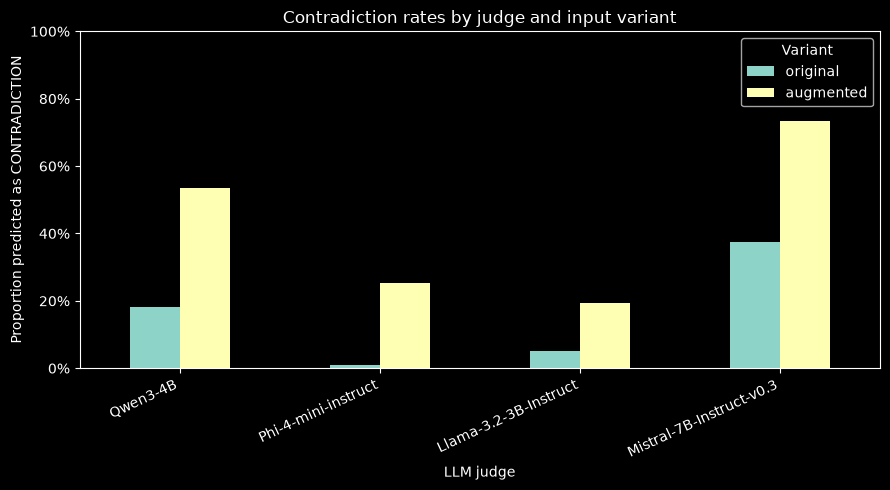

In [23]:
ax = (
    contradiction_rates[
        [
            "original",
            "augmented",
        ]
    ]
    .plot(
        kind="bar",
        figsize=(
            9,
            5,
        ),
    )
)


ax.set_xlabel(
    "LLM judge"
)

ax.set_ylabel(
    "Proportion predicted as CONTRADICTION"
)

ax.set_title(
    "Contradiction rates by judge and input variant"
)

ax.yaxis.set_major_formatter(
    PercentFormatter(
        xmax=1
    )
)

ax.set_ylim(
    0,
    1,
)

ax.legend(
    title="Variant"
)

plt.xticks(
    rotation=25,
    ha="right",
)

plt.tight_layout()
plt.show()

The four judges have visibly different contradiction tendencies.

Across all examples, Mistral predicts `CONTRADICTION` most frequently
(55.5%), followed by Qwen (35.9%). Phi (13.2%) and Llama (12.2%) are much
more conservative.

The same qualitative pattern is visible within both experimental variants.
For every judge, the contradiction rate is higher on augmented than on
original personas.

These differences motivate distinguishing **agreement** between judges from
their overall **tendency to predict contradictions**. A formal hypothesis test
of the latter is performed later in this section.

### 4.2 Pairwise agreement and Cohen's kappa

For each pair of judges, I calculate raw agreement and Cohen's kappa.

Raw agreement is the proportion of examples receiving the same binary label
from both judges.

Cohen's kappa is

\[
\kappa =
\frac{p_o - p_e}{1 - p_e},
\]

where \(p_o\) is the observed agreement and \(p_e\) is the agreement expected
from the judges' marginal label frequencies.

The statistics are calculated for all 2,000 examples together and separately
for the 1,000 original and 1,000 augmented examples.

In [24]:
from itertools import combinations


def compute_pairwise_agreement(
    predictions: pd.DataFrame,
    prefix: str,
) -> pd.DataFrame:
    """
    Compute raw agreement and Cohen's kappa
    for every pair of judges.
    """
    rows = []

    for judge_a, judge_b in combinations(
        predictions.columns,
        2,
    ):
        paired = (
            predictions[
                [
                    judge_a,
                    judge_b,
                ]
            ]
            .dropna()
        )

        raw_agreement = (
            paired[
                judge_a
            ]
            .eq(
                paired[
                    judge_b
                ]
            )
            .mean()
        )

        kappa = (
            cohen_kappa_score(
                paired[
                    judge_a
                ],
                paired[
                    judge_b
                ],
            )
        )

        rows.append(
            {
                "judge_a": judge_a,
                "judge_b": judge_b,
                f"{prefix}_agreement":
                    raw_agreement,
                f"{prefix}_kappa":
                    kappa,
            }
        )

    return pd.DataFrame(
        rows
    )

In [25]:
original_example_ids = (
    prediction_metadata[
        prediction_metadata[
            "variant"
        ].eq(
            "original"
        )
    ]
    .index
)


augmented_example_ids = (
    prediction_metadata[
        prediction_metadata[
            "variant"
        ].eq(
            "augmented"
        )
    ]
    .index
)


overall_pairwise = (
    compute_pairwise_agreement(
        prediction_matrix,
        prefix="overall",
    )
)


original_pairwise = (
    compute_pairwise_agreement(
        prediction_matrix.loc[
            original_example_ids
        ],
        prefix="original",
    )
)


augmented_pairwise = (
    compute_pairwise_agreement(
        prediction_matrix.loc[
            augmented_example_ids
        ],
        prefix="augmented",
    )
)


pairwise_agreement = (
    overall_pairwise
    .merge(
        original_pairwise,
        on=[
            "judge_a",
            "judge_b",
        ],
    )
    .merge(
        augmented_pairwise,
        on=[
            "judge_a",
            "judge_b",
        ],
    )
)

In [26]:
pairwise_agreement_display = (
    pairwise_agreement.copy()
)


agreement_columns = [
    "overall_agreement",
    "original_agreement",
    "augmented_agreement",
]


kappa_columns = [
    "overall_kappa",
    "original_kappa",
    "augmented_kappa",
]


for column in agreement_columns:
    pairwise_agreement_display[
        column
    ] = (
        pairwise_agreement_display[
            column
        ]
        .map(
            lambda value:
                f"{value:.1%}"
        )
    )


for column in kappa_columns:
    pairwise_agreement_display[
        column
    ] = (
        pairwise_agreement_display[
            column
        ]
        .round(3)
    )


pairwise_agreement_display

,judge_a,judge_b,overall_agreement,overall_kappa,original_agreement,original_kappa,augmented_agreement,augmented_kappa
0,Qwen3-4B,Phi-4-mini-instruct,73.0%,0.319,82.2%,0.053,63.9%,0.303
1,Qwen3-4B,Llama-3.2-3B-Instruct,70.9%,0.258,82.3%,0.169,59.4%,0.222
2,Qwen3-4B,Mistral-7B-Instruct-v0.3,68.0%,0.379,70.0%,0.286,66.0%,0.296
3,Phi-4-mini-instruct,Llama-3.2-3B-Instruct,85.4%,0.342,95.1%,0.182,75.7%,0.303
4,Phi-4-mini-instruct,Mistral-7B-Instruct-v0.3,55.5%,0.177,63.2%,0.026,47.9%,0.154
5,Llama-3.2-3B-Instruct,Mistral-7B-Instruct-v0.3,54.6%,0.162,66.3%,0.130,43.0%,0.114


Pairwise agreement varies substantially across judge pairs.

Across the complete experiment, raw agreement ranges from 54.6% for
Llama–Mistral to 85.4% for Phi–Llama. The corresponding Cohen's kappa values
range from 0.162 to 0.379.

The difference between raw agreement and kappa is particularly visible for
the original examples. For example, Phi and Llama agree on 95.1% of original
examples, but their Cohen's kappa is only 0.182. Both judges predict
`NO_CONTRADICTION` on most original examples, so a large part of the raw
agreement is explained by their strongly imbalanced marginal prediction
frequencies.

Agreement is generally lower on augmented examples than on original examples,
whereas kappa is often higher. This again illustrates why raw agreement and
chance-corrected agreement should be considered together.

### 4.3 Agreement among all four judges

Pairwise Cohen's kappa considers two judges at a time. As an additional
summary, Fleiss' kappa is used to describe agreement among all four judges
simultaneously.

It is calculated separately for original and augmented examples because the
label distributions differ strongly between these two variants.

In [27]:
from statsmodels.stats.inter_rater import (
    aggregate_raters,
    fleiss_kappa,
)


def compute_fleiss_kappa(
    predictions: pd.DataFrame,
) -> float:
    ratings = (
        predictions
        .astype(int)
        .to_numpy()
    )

    rating_counts, _ = (
        aggregate_raters(
            ratings,
            n_cat=2,
        )
    )

    return float(
        fleiss_kappa(
            rating_counts,
            method="fleiss",
        )
    )


multi_judge_agreement = pd.DataFrame(
    {
        "examples": [
            len(
                original_example_ids
            ),
            len(
                augmented_example_ids
            ),
        ],
        "fleiss_kappa": [
            compute_fleiss_kappa(
                prediction_matrix.loc[
                    original_example_ids
                ]
            ),
            compute_fleiss_kappa(
                prediction_matrix.loc[
                    augmented_example_ids
                ]
            ),
        ],
    },
    index=[
        "original",
        "augmented",
    ],
)


multi_judge_agreement[
    "fleiss_kappa"
] = (
    multi_judge_agreement[
        "fleiss_kappa"
    ]
    .round(3)
)


multi_judge_agreement

,examples,fleiss_kappa
original,1000,0.10
augmented,1000,0.17


Fleiss' kappa is 0.100 for original examples and 0.170 for augmented examples.

Thus, agreement among all four judges beyond agreement expected from their
marginal prediction frequencies is relatively low in both variants. The
slightly higher value for augmented examples is consistent with the
pairwise-kappa results, despite lower raw agreement on many augmented
comparisons.

### 4.4 Permutation test of judge differences

The contradiction rates in Section 4.1 suggest that the four judges have
different tendencies to predict `CONTRADICTION`.

I test the null hypothesis

\[
H_0:
\text{there is no systematic association between judge identity and
contradiction tendency,}
\]

against

\[
H_1:
\text{at least one judge has a systematically different contradiction tendency.}
\]

Under the null hypothesis, judge identities are treated as exchangeable within
each matched dialogue pair.

For every pair, the four judge identities are randomly permuted. The same
permutation is applied to both the original and augmented variant so that the
paired structure of the experiment is preserved.

The test statistic measures dispersion among the four contradiction rates:

\[
T =
\sum_{j=1}^{4}
(\hat p_j-\bar p)^2.
\]

Large values indicate stronger differences between the judges.

The null distribution is approximated using 10,000 random permutations.

In [28]:
judge_names = list(
    prediction_matrix.columns
)


original_predictions = (
    prediction_metadata
    .join(
        prediction_matrix
    )
    .query(
        "variant == 'original'"
    )
    .set_index(
        "pair_id"
    )[
        judge_names
    ]
    .sort_index()
)


augmented_predictions = (
    prediction_metadata
    .join(
        prediction_matrix
    )
    .query(
        "variant == 'augmented'"
    )
    .set_index(
        "pair_id"
    )[
        judge_names
    ]
    .sort_index()
)


assert (
    original_predictions.index
    .equals(
        augmented_predictions.index
    )
)


pair_judge_predictions = np.stack(
    [
        original_predictions.to_numpy(),
        augmented_predictions.to_numpy(),
    ],
    axis=1,
)

In [29]:
def judge_rate_dispersion(
    predictions: np.ndarray,
) -> float:
    rates = predictions.mean(
        axis=(
            0,
            1,
        )
    )

    return float(
        np.sum(
            (
                rates
                - rates.mean()
            )
            ** 2
        )
    )


observed_dispersion = (
    judge_rate_dispersion(
        pair_judge_predictions
    )
)


observed_rates = (
    pair_judge_predictions
    .mean(
        axis=(
            0,
            1,
        )
    )
)


observed_rate_range = float(
    observed_rates.max()
    - observed_rates.min()
)


rng = np.random.default_rng(
    RANDOM_SEED
)

N_PERMUTATIONS = 10_000

null_dispersion = np.empty(
    N_PERMUTATIONS
)


for permutation_id in range(
    N_PERMUTATIONS
):
    judge_permutations = np.argsort(
        rng.random(
            (
                N_PAIRS,
                len(judge_names),
            )
        ),
        axis=1,
    )

    permuted = np.take_along_axis(
        pair_judge_predictions,
        judge_permutations[
            :,
            None,
            :,
        ],
        axis=2,
    )

    null_dispersion[
        permutation_id
    ] = judge_rate_dispersion(
        permuted
    )


judge_difference_p_value = (
    1
    + np.sum(
        null_dispersion
        >= observed_dispersion
    )
) / (
    N_PERMUTATIONS
    + 1
)

In [30]:
judge_difference_result = pd.DataFrame(
    {
        "value": [
            observed_dispersion,
            observed_rate_range,
            N_PERMUTATIONS,
            judge_difference_p_value,
        ],
    },
    index=[
        "observed_rate_dispersion",
        "max_minus_min_rate",
        "permutations",
        "p_value",
    ],
)


judge_difference_result

,value
observed_rate_dispersion,0.127828
max_minus_min_rate,0.432500
permutations,10000.000000
p_value,0.000100


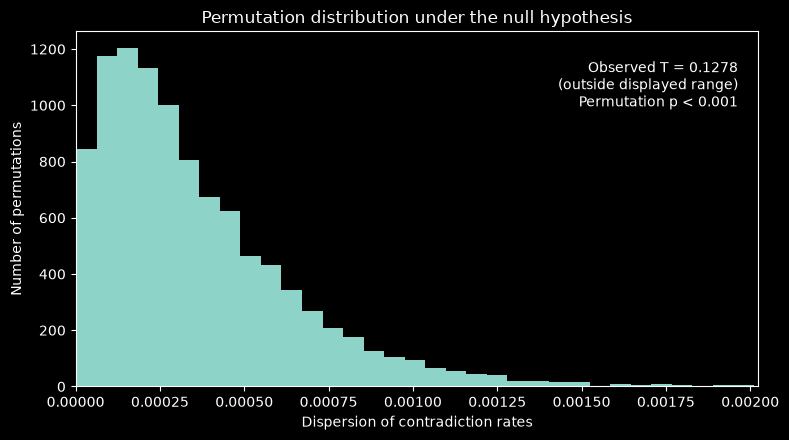

In [31]:
null_upper = np.quantile(
    null_dispersion,
    0.999,
)


fig, ax = plt.subplots(
    figsize=(
        8,
        4.5,
    )
)


ax.hist(
    null_dispersion,
    bins=40,
)


ax.set_xlim(
    0,
    null_upper * 1.1,
)


ax.text(
    0.97,
    0.92,
    (
        f"Observed T = {observed_dispersion:.4f}\n"
        f"(outside displayed range)\n"
        f"Permutation p < 0.001"
    ),
    transform=ax.transAxes,
    ha="right",
    va="top",
)


ax.set_xlabel(
    "Dispersion of contradiction rates"
)

ax.set_ylabel(
    "Number of permutations"
)

ax.set_title(
    "Permutation distribution under the null hypothesis"
)

plt.tight_layout()
plt.show()

The observed contradiction rates differ by as much as 43.3 percentage points
between judges.

The observed rate dispersion is \(T=0.1278\). None of the 10,000 random
permutations produced a dispersion at least as large as the observed value,
giving a Monte Carlo permutation \(p<0.001\).

The null hypothesis is therefore rejected at the 5% significance level. The
data provide strong evidence that the four LLM judges have systematically
different tendencies to label examples as contradictory.

## 5. Effect of contradiction-oriented augmentation

The experimental design also allows a paired comparison of the original and
augmented personas.

For each dialogue pair, let

\[
O_i
\]

denote the number of the four judges predicting `CONTRADICTION` for the
original persona and

\[
A_i
\]

the corresponding number for the augmented persona.

The paired difference is

\[
D_i = A_i-O_i.
\]

A positive difference therefore means that more judges identified a
contradiction after the persona was augmented.

The mean paired difference

\[
\bar D
\]

is used as the primary estimate of the augmentation effect.

In [32]:
original_vote_counts = (
    pair_judge_predictions[
        :,
        0,
        :,
    ]
    .sum(axis=1)
    .astype(int)
)


augmented_vote_counts = (
    pair_judge_predictions[
        :,
        1,
        :,
    ]
    .sum(axis=1)
    .astype(int)
)


vote_differences = (
    augmented_vote_counts
    - original_vote_counts
)

In [33]:
augmentation_summary = pd.DataFrame(
    {
        "value": [
            len(
                vote_differences
            ),
            original_vote_counts.mean(),
            augmented_vote_counts.mean(),
            vote_differences.mean(),
            np.median(
                vote_differences
            ),
            (
                vote_differences
                > 0
            ).mean(),
            (
                vote_differences
                == 0
            ).mean(),
            (
                vote_differences
                < 0
            ).mean(),
        ],
    },
    index=[
        "pairs",
        "mean_original_C_votes",
        "mean_augmented_C_votes",
        "mean_vote_difference",
        "median_vote_difference",
        "positive_difference_rate",
        "zero_difference_rate",
        "negative_difference_rate",
    ],
)


augmentation_summary

,value
pairs,1000.000
mean_original_C_votes,0.617
mean_augmented_C_votes,1.717
mean_vote_difference,1.100
median_vote_difference,1.000
positive_difference_rate,0.605
zero_difference_rate,0.372
negative_difference_rate,0.023


In [34]:
augmentation_difference_distribution = (
    pd.Series(
        vote_differences,
        name="vote_difference",
    )
    .value_counts()
    .sort_index()
    .rename(
        "pairs"
    )
    .to_frame()
)


augmentation_difference_distribution[
    "proportion"
] = (
    augmentation_difference_distribution[
        "pairs"
    ]
    / len(
        vote_differences
    )
)


augmentation_difference_distribution

,pairs,proportion
vote_difference,,
-2,1,0.001
-1,22,0.022
0,372,0.372
1,265,0.265
2,197,0.197
3,107,0.107
4,36,0.036


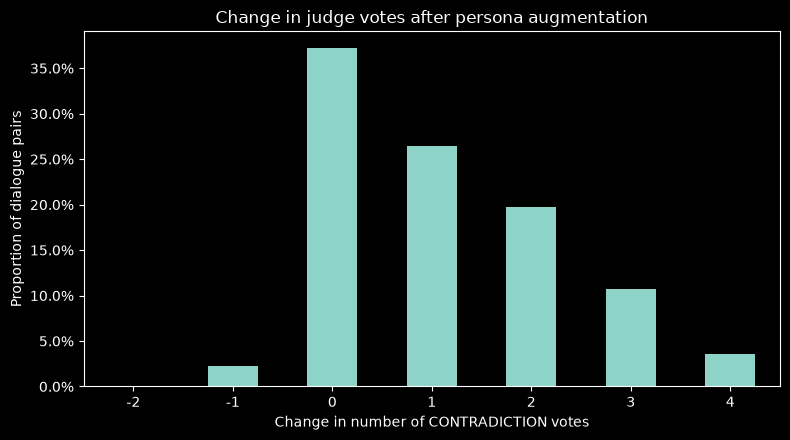

In [35]:
ax = (
    augmentation_difference_distribution[
        "proportion"
    ]
    .plot(
        kind="bar",
        figsize=(
            8,
            4.5,
        ),
    )
)


ax.set_xlabel(
    "Change in number of CONTRADICTION votes"
)

ax.set_ylabel(
    "Proportion of dialogue pairs"
)

ax.set_title(
    "Change in judge votes after persona augmentation"
)

ax.yaxis.set_major_formatter(
    PercentFormatter(
        xmax=1
    )
)

plt.xticks(
    rotation=0
)

plt.tight_layout()
plt.show()

The augmentation produces a strong directional shift in the judges'
decisions.

The mean number of contradiction votes increases from 0.617 out of four on
the original personas to 1.717 on the augmented personas. The mean paired
increase is therefore 1.100 contradiction votes.

For 60.5% of dialogue pairs the number of contradiction votes increases,
37.2% remain unchanged, and only 2.3% move in the opposite direction.

The effect is therefore not driven by a small number of extreme examples:
positive changes are substantially more common than negative changes.

### 5.2 Paired permutation test

To test whether the directional increase could be explained under a null model
with no systematic augmentation effect, I use a paired permutation test.

The hypotheses are

\[
H_0:
\text{the original and augmented labels are exchangeable within each pair,}
\]

against the one-sided alternative

\[
H_1:
\text{augmentation increases the number of contradiction votes.}
\]

Swapping the original and augmented variants within a pair changes
\(D_i\) into \(-D_i\). A permutation sample can therefore be generated by
randomly choosing the sign of each paired difference.

The test statistic is the mean paired difference \(\bar D\). The null
distribution is approximated using 10,000 permutations.

In [36]:
rng = np.random.default_rng(
    RANDOM_SEED
)


observed_mean_difference = float(
    vote_differences.mean()
)


augmentation_null_means = np.empty(
    N_PERMUTATIONS
)


for permutation_id in range(
    N_PERMUTATIONS
):
    signs = rng.choice(
        [
            -1,
            1,
        ],
        size=len(
            vote_differences
        ),
    )

    augmentation_null_means[
        permutation_id
    ] = (
        vote_differences
        * signs
    ).mean()


augmentation_p_value = (
    1
    + np.sum(
        augmentation_null_means
        >= observed_mean_difference
    )
) / (
    N_PERMUTATIONS
    + 1
)

In [37]:
augmentation_permutation_result = pd.DataFrame(
    {
        "value": [
            len(
                vote_differences
            ),
            observed_mean_difference,
            N_PERMUTATIONS,
            augmentation_p_value,
        ],
    },
    index=[
        "pairs",
        "observed_mean_difference",
        "permutations",
        "p_value",
    ],
)


augmentation_permutation_result

,value
pairs,1000.0000
observed_mean_difference,1.1000
permutations,10000.0000
p_value,0.0001


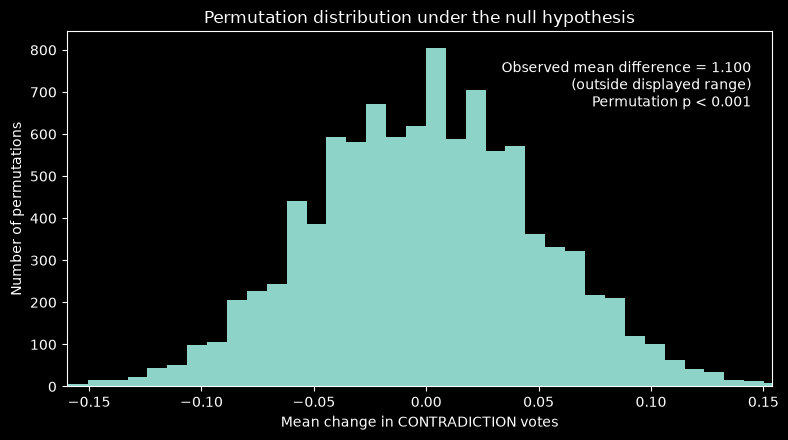

In [38]:
null_lower = np.quantile(
    augmentation_null_means,
    0.001,
)

null_upper = np.quantile(
    augmentation_null_means,
    0.999,
)


fig, ax = plt.subplots(
    figsize=(
        8,
        4.5,
    )
)


ax.hist(
    augmentation_null_means,
    bins=40,
)


ax.set_xlim(
    null_lower,
    null_upper,
)


ax.text(
    0.97,
    0.92,
    (
        f"Observed mean difference = "
        f"{observed_mean_difference:.3f}\n"
        f"(outside displayed range)\n"
        f"Permutation p < 0.001"
    ),
    transform=ax.transAxes,
    ha="right",
    va="top",
)


ax.set_xlabel(
    "Mean change in CONTRADICTION votes"
)

ax.set_ylabel(
    "Number of permutations"
)

ax.set_title(
    "Permutation distribution under the null hypothesis"
)

plt.tight_layout()
plt.show()

The observed mean increase is 1.100 contradiction votes.

None of the 10,000 random permutations produced a mean increase at least as
large as the observed value, corresponding to a Monte Carlo permutation
\(p<0.001\).

The null hypothesis is therefore rejected. The results provide strong evidence
that the contradiction-oriented persona augmentation systematically increases
the number of judges identifying a contradiction.

### 5.3 Bootstrap confidence interval

The permutation test addresses the existence and direction of the effect. To
quantify its magnitude and uncertainty, I estimate a 95% bootstrap confidence
interval for the mean paired difference.

A bootstrap sample is constructed by sampling the 1,000 dialogue pairs with
replacement and recalculating the mean paired difference.

This is repeated 10,000 times. The 2.5th and 97.5th percentiles of the
bootstrap distribution form the 95% percentile bootstrap confidence interval.

In [39]:
rng = np.random.default_rng(
    RANDOM_SEED
)

N_BOOTSTRAP = 10_000


bootstrap_mean_differences = np.empty(
    N_BOOTSTRAP
)


for bootstrap_id in range(
    N_BOOTSTRAP
):
    bootstrap_sample = rng.choice(
        vote_differences,
        size=len(
            vote_differences
        ),
        replace=True,
    )

    bootstrap_mean_differences[
        bootstrap_id
    ] = (
        bootstrap_sample.mean()
    )


bootstrap_ci_lower = float(
    np.quantile(
        bootstrap_mean_differences,
        0.025,
    )
)


bootstrap_ci_upper = float(
    np.quantile(
        bootstrap_mean_differences,
        0.975,
    )
)

In [40]:
augmentation_effect_result = pd.DataFrame(
    {
        "value": [
            observed_mean_difference,
            bootstrap_ci_lower,
            bootstrap_ci_upper,
            N_BOOTSTRAP,
        ],
    },
    index=[
        "mean_vote_increase",
        "bootstrap_95_ci_lower",
        "bootstrap_95_ci_upper",
        "bootstrap_samples",
    ],
)


augmentation_effect_result

,value
mean_vote_increase,1.100
bootstrap_95_ci_lower,1.026
bootstrap_95_ci_upper,1.172
bootstrap_samples,10000.000


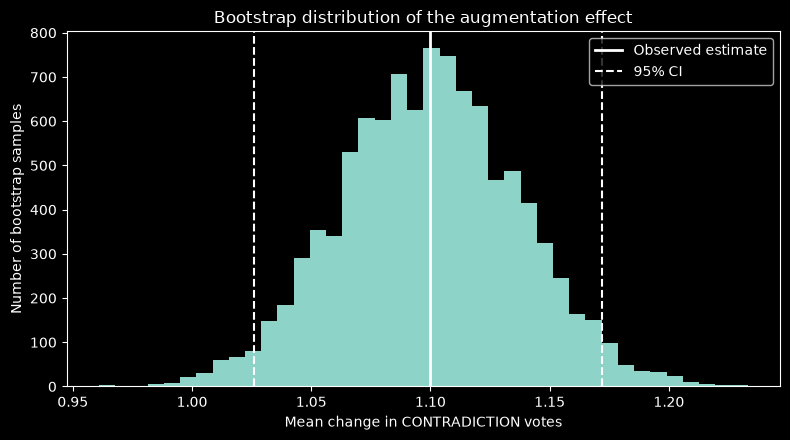

In [41]:
fig, ax = plt.subplots(
    figsize=(
        8,
        4.5,
    )
)


ax.hist(
    bootstrap_mean_differences,
    bins=40,
)


ax.axvline(
    observed_mean_difference,
    linewidth=2,
    label="Observed estimate",
)


ax.axvline(
    bootstrap_ci_lower,
    linestyle="--",
    label="95% CI",
)


ax.axvline(
    bootstrap_ci_upper,
    linestyle="--",
)


ax.set_xlabel(
    "Mean change in CONTRADICTION votes"
)

ax.set_ylabel(
    "Number of bootstrap samples"
)

ax.set_title(
    "Bootstrap distribution of the augmentation effect"
)

ax.legend()

plt.tight_layout()
plt.show()

The estimated mean augmentation effect is an increase of **1.100 contradiction
votes out of four judges**.

The 95% percentile bootstrap confidence interval is

\[
[1.026,\ 1.172].
\]

Thus, in this sample, contradiction-oriented augmentation increases the number
of judges identifying a contradiction by approximately one additional judge
per dialogue pair on average.

The confidence interval is far above zero and is consistent with the strong
directional evidence from the paired permutation test.

## 6. Input characteristics

### 6.1 Input length

The original project proposal also considers whether judge decisions are
related to properties of the evaluated input.

I use **input length** as the primary textual characteristic. The analysis is
restricted to the 1,000 augmented examples, giving one observation per sampled
dialogue and avoiding the strong original–augmented difference as a
confounding factor.

For each example, the response variable is

\[
Y_i =
\frac{\text{number of judges predicting CONTRADICTION}}{4},
\]

so that

\[
Y_i \in \{0,\ 0.25,\ 0.50,\ 0.75,\ 1\}.
\]

A simple linear regression is used to summarize the relationship between input
length and contradiction vote share. Input length is measured in units of 100
words, making the regression slope directly interpretable as the change in
vote share associated with 100 additional input words.

In [42]:
augmented_input_df = (
    experiment_df[
        experiment_df[
            "variant"
        ].eq(
            "augmented"
        )
    ][
        [
            "example_id",
            "pair_id",
            "input_length",
        ]
    ]
    .drop_duplicates(
        "example_id"
    )
    .set_index(
        "example_id"
    )
    .join(
        prediction_matrix
    )
)


judge_columns = list(
    prediction_matrix.columns
)


augmented_input_df[
    "contradiction_vote_share"
] = (
    augmented_input_df[
        judge_columns
    ]
    .sum(
        axis=1
    )
    / len(
        judge_columns
    )
)


assert len(
    augmented_input_df
) == 1000

In [43]:
x = (
    augmented_input_df[
        "input_length"
    ]
    .to_numpy()
    / 100
)


y = (
    augmented_input_df[
        "contradiction_vote_share"
    ]
    .to_numpy()
)


observed_slope, observed_intercept = (
    np.polyfit(
        x,
        y,
        deg=1,
    )
)


observed_correlation = float(
    np.corrcoef(
        x,
        y,
    )[0, 1]
)


input_length_summary = pd.DataFrame(
    {
        "value": [
            observed_slope,
            observed_slope * 100,
            observed_correlation,
        ],
    },
    index=[
        "slope_per_100_words",
        "vote_share_change_pp_per_100_words",
        "pearson_correlation",
    ],
)


input_length_summary

,value
slope_per_100_words,-0.036934
vote_share_change_pp_per_100_words,-3.693414
pearson_correlation,-0.035978


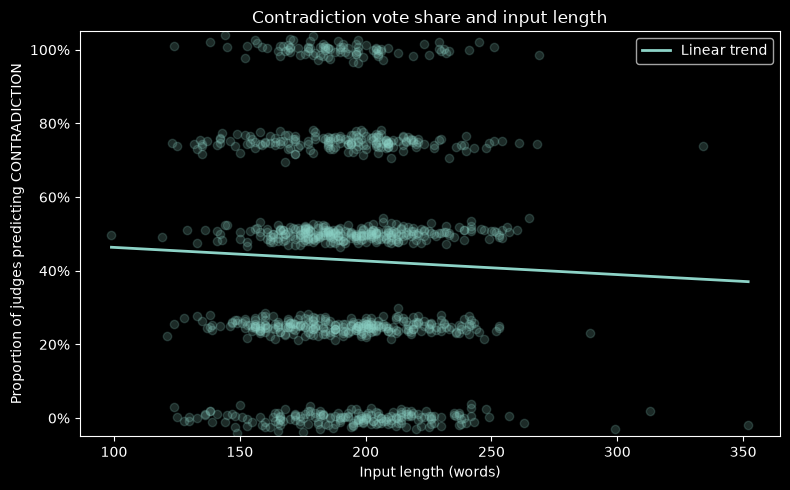

In [44]:
rng = np.random.default_rng(
    RANDOM_SEED
)


plot_y = (
    y
    + rng.normal( 0, 0.015, size=len(y))
)


x_words = (
    x
    * 100
)


x_line_words = np.linspace(
    x_words.min(),
    x_words.max(),
    200,
)


y_line = (
    observed_intercept
    + observed_slope
    * (
        x_line_words
        / 100
    )
)


fig, ax = plt.subplots(
    figsize=(
        8,
        5,
    )
)


ax.scatter(
    x_words,
    plot_y,
    alpha=0.2,
)


ax.plot(
    x_line_words,
    y_line,
    linewidth=2,
    label="Linear trend",
)


ax.set_xlabel(
    "Input length (words)"
)

ax.set_ylabel(
    "Proportion of judges predicting CONTRADICTION"
)

ax.set_title(
    "Contradiction vote share and input length"
)

ax.set_ylim(
    -0.05,
    1.05,
)

ax.yaxis.set_major_formatter(
    PercentFormatter(
        xmax=1
    )
)

ax.legend()

plt.tight_layout()
plt.show()

To test the linear relationship formally, I use a permutation test with the
regression slope as the test statistic.

The null hypothesis is that contradiction vote share is not systematically
associated with input length. Under this null model, the vote-share values are
exchangeable with respect to input length.

I therefore randomly permute the vote shares among the 1,000 augmented
examples while keeping input lengths fixed. For each of 10,000 permutations,
the regression slope is recalculated.

Because the slope is used as the test statistic, this analysis specifically
targets a **linear trend**. The two-sided p-value is the proportion of
permutations whose absolute slope is at least as large as the observed
absolute slope.

In [45]:
N_INPUT_PERMUTATIONS = 10_000

rng = np.random.default_rng(
    RANDOM_SEED
)


null_slopes = np.empty(
    N_INPUT_PERMUTATIONS
)


for permutation_id in range(
    N_INPUT_PERMUTATIONS
):
    permuted_y = rng.permutation(
        y
    )

    null_slopes[
        permutation_id
    ] = np.polyfit(
        x,
        permuted_y,
        deg=1,
    )[0]


input_length_p_value = (
    1
    + np.sum(
        np.abs(
            null_slopes
        )
        >= abs(
            observed_slope
        )
    )
) / (
    N_INPUT_PERMUTATIONS
    + 1
)

In [46]:
input_length_test_result = pd.DataFrame(
    {
        "value": [
            len(
                augmented_input_df
            ),
            observed_slope,
            observed_slope * 100,
            observed_correlation,
            N_INPUT_PERMUTATIONS,
            input_length_p_value,
        ],
    },
    index=[
        "examples",
        "slope_per_100_words",
        "vote_share_change_pp_per_100_words",
        "pearson_correlation",
        "permutations",
        "p_value",
    ],
)


input_length_test_result

,value
examples,1000.000000
slope_per_100_words,-0.036934
vote_share_change_pp_per_100_words,-3.693414
pearson_correlation,-0.035978
permutations,10000.000000
p_value,0.257174


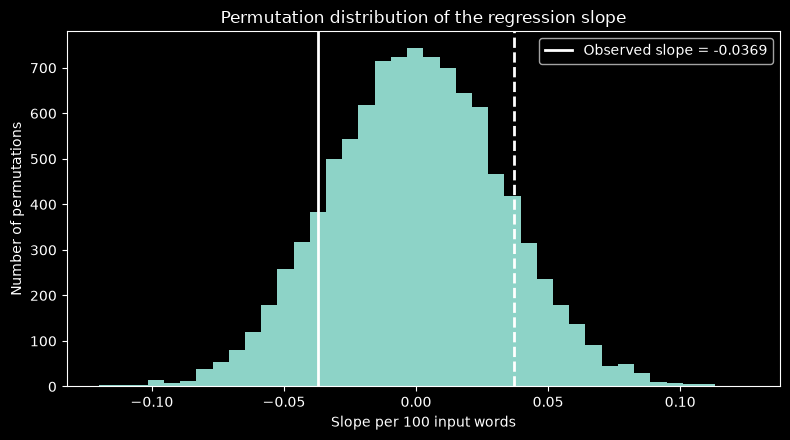

In [47]:
fig, ax = plt.subplots(
    figsize=(
        8,
        4.5,
    )
)


ax.hist(
    null_slopes,
    bins=40,
)


ax.axvline(
    observed_slope,
    linewidth=2,
    label=(
        f"Observed slope = "
        f"{observed_slope:.4f}"
    ),
)


ax.axvline(
    -observed_slope,
    linewidth=2,
    linestyle="--",
)


ax.set_xlabel(
    "Slope per 100 input words"
)

ax.set_ylabel(
    "Number of permutations"
)

ax.set_title(
    "Permutation distribution of the regression slope"
)

ax.legend()

plt.tight_layout()
plt.show()

The estimated slope is \(-0.0369\), corresponding to an estimated decrease of
approximately 3.7 percentage points in contradiction vote share for every
additional 100 input words.

However, the linear association is very weak
(\(r=-0.036\)). The permutation test gives \(p=0.257\), so the null hypothesis
of zero linear slope is not rejected at the 5% significance level.

The analysis therefore does not provide evidence for a systematic **linear**
relationship between input length and contradiction vote share. This result
specifically concerns a linear trend and should not be interpreted as proof
that input length is completely unrelated to judge behaviour.

### 6.2 Augmentation type

As a secondary exploratory analysis, I examine whether contradiction detection
differs across types of rule-based persona augmentation.

A single persona can contain several augmented facts and may therefore contain
multiple augmentation types. Comparing such profiles directly would make it
difficult to attribute judge behaviour to a particular augmentation category.

I therefore restrict the primary comparison to profiles containing exactly one
**unique augmentation type**. Repeated applications of the same rule type
within a persona are still considered single-type profiles.

Of the 1,000 augmented profiles, 702 (70.2%) satisfy this condition.

For each augmentation type, I report the number of profiles and the mean
proportion of the four judges predicting `CONTRADICTION`.

Because category sizes are highly unequal and several augmentation types have
small sample sizes, this analysis is treated as **exploratory rather than
confirmatory**. No hypothesis tests are performed between augmentation
categories.

In [48]:
def unique_augmentation_types(
    values,
) -> tuple[str, ...]:
    """Return unique augmentation types in first-occurrence order."""
    return tuple(
        dict.fromkeys(
            str(value)
            for value in values
        )
    )


augmentation_type_df = (
    experiment_df[
        experiment_df[
            "variant"
        ].eq(
            "augmented"
        )
    ][
        [
            "example_id",
            "pair_id",
            "augmentation_types",
        ]
    ]
    .drop_duplicates(
        "example_id"
    )
    .set_index(
        "example_id"
    )
    .join(
        prediction_matrix
    )
)


augmentation_type_df[
    "unique_augmentation_types"
] = (
    augmentation_type_df[
        "augmentation_types"
    ]
    .map(
        unique_augmentation_types
    )
)


augmentation_type_df[
    "num_unique_augmentation_types"
] = (
    augmentation_type_df[
        "unique_augmentation_types"
    ]
    .map(len)
)


augmentation_type_df[
    "contradiction_votes"
] = (
    augmentation_type_df[
        list(
            prediction_matrix.columns
        )
    ]
    .sum(
        axis=1
    )
    .astype(int)
)


augmentation_type_df[
    "contradiction_vote_share"
] = (
    augmentation_type_df[
        "contradiction_votes"
    ]
    / len(
        prediction_matrix.columns
    )
)

In [49]:
single_type_df = (
    augmentation_type_df[
        augmentation_type_df[
            "num_unique_augmentation_types"
        ].eq(1)
    ]
    .copy()
)


single_type_df[
    "augmentation_type"
] = (
    single_type_df[
        "unique_augmentation_types"
    ]
    .map(
        lambda values:
            values[0]
    )
)


assert len(
    augmentation_type_df
) == 1000

assert len(
    single_type_df
) == 702

In [50]:
augmentation_type_summary = (
    single_type_df
    .groupby(
        "augmentation_type",
        observed=True,
    )
    .agg(
        profiles=(
            "pair_id",
            "size",
        ),
        mean_contradiction_votes=(
            "contradiction_votes",
            "mean",
        ),
        mean_vote_share=(
            "contradiction_vote_share",
            "mean",
        ),
    )
    .sort_values(
        "mean_vote_share",
        ascending=False,
    )
)


augmentation_type_summary[
    "mean_contradiction_votes"
] = (
    augmentation_type_summary[
        "mean_contradiction_votes"
    ]
    .round(3)
)


augmentation_type_summary_display = (
    augmentation_type_summary.copy()
)


augmentation_type_summary_display[
    "mean_vote_share"
] = (
    augmentation_type_summary_display[
        "mean_vote_share"
    ]
    .map(
        lambda value:
            f"{value:.1%}"
    )
)


augmentation_type_summary_display

,profiles,mean_contradiction_votes,mean_vote_share
augmentation_type,,,
preference_negation,378,1.995,49.9%
aspiration_negation,34,1.882,47.1%
diet_swap,11,1.636,40.9%
age_swap,21,1.571,39.3%
family_composition_swap,35,1.486,37.1%
location_swap,20,1.050,26.2%
count_swap,18,1.000,25.0%
living_situation_swap,13,0.923,23.1%
favorite_swap,87,0.724,18.1%


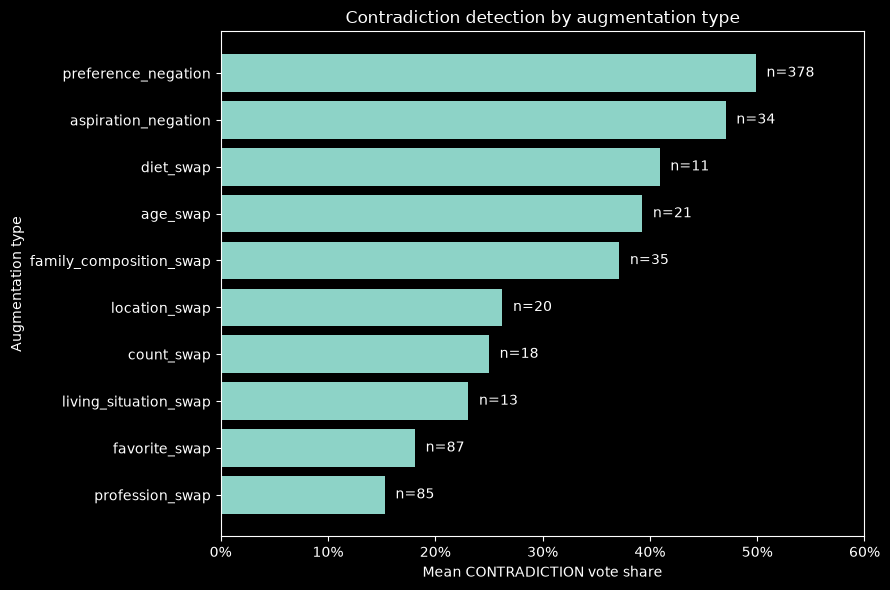

In [51]:
augmentation_type_plot = (
    augmentation_type_summary
    .sort_values(
        "mean_vote_share",
        ascending=True,
    )
)


fig, ax = plt.subplots(
    figsize=(
        9,
        6,
    )
)


bars = ax.barh(
    augmentation_type_plot.index,
    augmentation_type_plot[
        "mean_vote_share"
    ],
)


ax.set_xlabel(
    "Mean CONTRADICTION vote share"
)

ax.set_ylabel(
    "Augmentation type"
)

ax.set_title(
    "Contradiction detection by augmentation type"
)

ax.xaxis.set_major_formatter(
    PercentFormatter(
        xmax=1
    )
)


for bar, profiles in zip(
    bars,
    augmentation_type_plot[
        "profiles"
    ],
):
    ax.text(
        bar.get_width() + 0.01,
        bar.get_y()
        + bar.get_height() / 2,
        f"n={profiles}",
        va="center",
    )


ax.set_xlim(
    0,
    0.6,
)

plt.tight_layout()
plt.show()

Contradiction detection varies substantially across augmentation categories.

The two highest-detection categories are `preference_negation`, with a mean
contradiction vote share of 49.9% (\(n=378\)), and
`aspiration_negation`, with 47.1% (\(n=34\)).

At the other end of the distribution, `favorite_swap` has a mean vote share
of 18.1% (\(n=87\)) and `profession_swap` only 15.3% (\(n=85\)).

This suggests that explicit polarity-changing augmentations such as preference
and aspiration negation are more readily identified by the LLM judges than
some replacement-based augmentations such as favorite or profession swaps.

The smaller categories should be interpreted cautiously. For example,
`diet_swap` contains only 11 single-type profiles and `living_situation_swap`
only 13. The results therefore describe patterns in this experimental sample
rather than establishing statistically significant differences between
augmentation types.

## 7. Prompt robustness

The final analysis examines whether an individual LLM judge makes similar
decisions after a small reformulation of the evaluation prompt.

The baseline prompt `full_persona_v3` is compared with
`full_persona_robustness_v1`. The alternative prompt preserves the same
definition of contradiction, the same SELF/PARTNER distinction, the same
decision rules, and the same binary output labels, but reformulates and
reorders the instructions.

The comparison uses a frozen subset of 50 dialogue pairs, corresponding to
100 examples (50 original and 50 augmented). Both prompts are evaluated on
exactly the same examples.

For each judge, model revision and deterministic decoding settings are held
fixed, so prompt wording is the intended experimental difference.

Prompt robustness is described using:

- raw agreement between baseline and alternate-prompt decisions,
- Cohen's kappa,
- the change in overall contradiction rate,
- the number and direction of changed decisions,
- a 95% bootstrap confidence interval for raw agreement.

For the bootstrap, dialogue pairs rather than individual examples are sampled
with replacement, preserving the original–augmented pairing.

The 50 dialogue pairs used for prompt robustness are a fixed subset of the
1,000-pair experimental sample. They were selected before the
alternative-prompt results were inspected, using the same fixed random seed
(\(42\)). The resulting 100-example subset is stored in

`data/llm_judge_pilot_v1.parquet`.

The alternative-prompt evaluations are generated using the same inference
script as the main experiment:

`scripts/run_llm_judge.py`

with `--prompt-id full_persona_robustness_v1`.

The four runs can be reproduced using:

```bash
python -m scripts.run_llm_judge \
  --input data/llm_judge_pilot_v1.parquet \
  --output outputs/judgments/qwen3_4b_prompt_robustness_v1.parquet \
  --model-name Qwen/Qwen3-4B \
  --model-id qwen3_4b \
  --prompt-id full_persona_robustness_v1 \
  --batch-size 4

python -m scripts.run_llm_judge \
  --input data/llm_judge_pilot_v1.parquet \
  --output outputs/judgments/phi4_mini_prompt_robustness_v1.parquet \
  --model-name microsoft/Phi-4-mini-instruct \
  --model-id phi4_mini \
  --prompt-id full_persona_robustness_v1 \
  --batch-size 4

python -m scripts.run_llm_judge \
  --input data/llm_judge_pilot_v1.parquet \
  --output outputs/judgments/llama32_3b_prompt_robustness_v1.parquet \
  --model-name meta-llama/Llama-3.2-3B-Instruct \
  --model-id llama32_3b \
  --prompt-id full_persona_robustness_v1 \
  --batch-size 4

python -m scripts.run_llm_judge \
  --input data/llm_judge_pilot_v1.parquet \
  --output outputs/judgments/mistral7b_prompt_robustness_v1.parquet \
  --model-name mistralai/Mistral-7B-Instruct-v0.3 \
  --model-id mistral7b \
  --prompt-id full_persona_robustness_v1 \
  --batch-size 2
```

In [52]:
PROMPT_ROBUSTNESS_CONFIGS = {
    "qwen3_4b": {
        "label": "Qwen3-4B",
        "baseline_file":
            "qwen3_4b_pilot_v3.parquet",
        "alternate_file":
            "qwen3_4b_prompt_robustness_v1.parquet",
    },
    "phi4_mini": {
        "label": "Phi-4-mini-instruct",
        "baseline_file":
            "phi4_mini_pilot_v3.parquet",
        "alternate_file":
            "phi4_mini_prompt_robustness_v1.parquet",
    },
    "llama32_3b": {
        "label": "Llama-3.2-3B-Instruct",
        "baseline_file":
            "llama32_3b_pilot_v3.parquet",
        "alternate_file":
            "llama32_3b_prompt_robustness_v1.parquet",
    },
    "mistral7b": {
        "label": "Mistral-7B-Instruct-v0.3",
        "baseline_file":
            "mistral7b_pilot_v3.parquet",
        "alternate_file":
            "mistral7b_prompt_robustness_v1.parquet",
    },
}


BASELINE_PROMPT_ID = (
    "full_persona_v3"
)

ALTERNATE_PROMPT_ID = (
    "full_persona_robustness_v1"
)

In [53]:
def load_prompt_results(
    path: str | Path,
    expected_prompt_id: str,
) -> pd.DataFrame:
    df = pd.read_parquet(
        path
    ).copy()

    assert (
        df[
            "prompt_id"
        ]
        .eq(
            expected_prompt_id
        )
        .all()
    )

    parsed = (
        df[
            "raw_output"
        ]
        .map(
            parse_judge_output
        )
    )

    df[
        "parsed_label"
    ] = parsed.map(
        lambda result:
            result[0]
    )

    df[
        "parsed_label_binary"
    ] = parsed.map(
        lambda result:
            result[1]
    )

    df[
        "valid_output"
    ] = (
        df[
            "parsed_label"
        ].notna()
    )

    return df

In [54]:
prompt_results = {}


for model_id, config in (
    PROMPT_ROBUSTNESS_CONFIGS.items()
):
    baseline = load_prompt_results(
        JUDGMENTS_DIR
        / config[
            "baseline_file"
        ],
        BASELINE_PROMPT_ID,
    )

    alternate = load_prompt_results(
        JUDGMENTS_DIR
        / config[
            "alternate_file"
        ],
        ALTERNATE_PROMPT_ID,
    )

    assert len(
        baseline
    ) == 100

    assert len(
        alternate
    ) == 100

    assert (
        set(
            baseline[
                "example_id"
            ]
        )
        == set(
            alternate[
                "example_id"
            ]
        )
    )

    assert (
        baseline[
            "pair_id"
        ].nunique()
        == 50
    )

    assert (
        alternate[
            "pair_id"
        ].nunique()
        == 50
    )

    assert (
        baseline[
            "valid_output"
        ].all()
    )

    assert (
        alternate[
            "valid_output"
        ].all()
    )

    assert (
        baseline[
            "model_revision"
        ].iloc[0]
        == alternate[
            "model_revision"
        ].iloc[0]
    )

    prompt_results[
        model_id
    ] = {
        "baseline":
            baseline,
        "alternate":
            alternate,
    }


print(
    "All prompt-robustness runs passed validation."
)

All prompt-robustness runs passed validation.


In [55]:
paired_prompt_results = {}


for model_id, results in (
    prompt_results.items()
):
    baseline = (
        results[
            "baseline"
        ][
            [
                "example_id",
                "pair_id",
                "variant",
                "parsed_label",
                "parsed_label_binary",
            ]
        ]
        .rename(
            columns={
                "parsed_label":
                    "baseline_label",
                "parsed_label_binary":
                    "baseline_binary",
            }
        )
    )

    alternate = (
        results[
            "alternate"
        ][
            [
                "example_id",
                "parsed_label",
                "parsed_label_binary",
            ]
        ]
        .rename(
            columns={
                "parsed_label":
                    "alternate_label",
                "parsed_label_binary":
                    "alternate_binary",
            }
        )
    )

    paired = baseline.merge(
        alternate,
        on="example_id",
        validate="one_to_one",
    )

    paired[
        "same_decision"
    ] = (
        paired[
            "baseline_binary"
        ]
        == paired[
            "alternate_binary"
        ]
    )

    paired_prompt_results[
        model_id
    ] = paired

In [56]:
def bootstrap_prompt_agreement(
    paired: pd.DataFrame,
    n_bootstrap: int = 10_000,
    seed: int = 42,
) -> tuple[
    float,
    float,
]:
    agreement_by_pair = (
        paired
        .assign(
            agreement=(
                paired[
                    "baseline_binary"
                ]
                == paired[
                    "alternate_binary"
                ]
            ).astype(float)
        )
        .groupby(
            "pair_id"
        )[
            "agreement"
        ]
        .mean()
    )

    pair_ids = (
        agreement_by_pair.index
        .to_numpy()
    )

    rng = np.random.default_rng(
        seed
    )

    bootstrap_agreements = np.empty(
        n_bootstrap
    )

    for bootstrap_id in range(
        n_bootstrap
    ):
        sampled_ids = rng.choice(
            pair_ids,
            size=len(
                pair_ids
            ),
            replace=True,
        )

        bootstrap_agreements[
            bootstrap_id
        ] = (
            agreement_by_pair
            .loc[
                sampled_ids
            ]
            .mean()
        )

    return (
        float(
            np.quantile(
                bootstrap_agreements,
                0.025,
            )
        ),
        float(
            np.quantile(
                bootstrap_agreements,
                0.975,
            )
        ),
    )

In [57]:
prompt_summary_rows = []


for model_id, paired in (
    paired_prompt_results.items()
):
    baseline_rate = (
        paired[
            "baseline_binary"
        ].mean()
    )

    alternate_rate = (
        paired[
            "alternate_binary"
        ].mean()
    )

    raw_agreement = (
        paired[
            "same_decision"
        ].mean()
    )

    kappa = cohen_kappa_score(
        paired[
            "baseline_binary"
        ],
        paired[
            "alternate_binary"
        ],
    )

    n_to_c = (
        (
            paired[
                "baseline_binary"
            ].eq(0)
        )
        & (
            paired[
                "alternate_binary"
            ].eq(1)
        )
    ).sum()

    c_to_n = (
        (
            paired[
                "baseline_binary"
            ].eq(1)
        )
        & (
            paired[
                "alternate_binary"
            ].eq(0)
        )
    ).sum()

    ci_lower, ci_upper = (
        bootstrap_prompt_agreement(
            paired,
            n_bootstrap=10_000,
            seed=RANDOM_SEED,
        )
    )

    prompt_summary_rows.append(
        {
            "judge":
                PROMPT_ROBUSTNESS_CONFIGS[
                    model_id
                ][
                    "label"
                ],
            "baseline_C_rate":
                baseline_rate,
            "alternate_C_rate":
                alternate_rate,
            "C_rate_change":
                alternate_rate
                - baseline_rate,
            "raw_agreement":
                raw_agreement,
            "cohen_kappa":
                kappa,
            "N_to_C":
                int(
                    n_to_c
                ),
            "C_to_N":
                int(
                    c_to_n
                ),
            "agreement_ci_lower":
                ci_lower,
            "agreement_ci_upper":
                ci_upper,
        }
    )


prompt_robustness_summary = (
    pd.DataFrame(
        prompt_summary_rows
    )
    .set_index(
        "judge"
    )
)


prompt_robustness_summary

,baseline_C_rate,alternate_C_rate,C_rate_change,raw_agreement,cohen_kappa,N_to_C,C_to_N,agreement_ci_lower,agreement_ci_upper
judge,,,,,,,,,
Qwen3-4B,0.26,0.05,-0.21,0.79,0.260563,0,21,0.70,0.87
Phi-4-mini-instruct,0.09,0.15,0.06,0.94,0.718310,6,0,0.89,0.98
Llama-3.2-3B-Instruct,0.08,0.28,0.20,0.76,0.238579,22,2,0.66,0.86
Mistral-7B-Instruct-v0.3,0.53,0.08,-0.45,0.53,0.105103,1,46,0.42,0.63


In [58]:
prompt_robustness_display = (
    prompt_robustness_summary.copy()
)


for column in [
    "baseline_C_rate",
    "alternate_C_rate",
    "C_rate_change",
    "raw_agreement",
    "agreement_ci_lower",
    "agreement_ci_upper",
]:
    prompt_robustness_display[
        column
    ] = (
        prompt_robustness_display[
            column
        ]
        .map(
            lambda value:
                f"{value:.1%}"
        )
    )


prompt_robustness_display[
    "cohen_kappa"
] = (
    prompt_robustness_display[
        "cohen_kappa"
    ]
    .round(3)
)


prompt_robustness_display

,baseline_C_rate,alternate_C_rate,C_rate_change,raw_agreement,cohen_kappa,N_to_C,C_to_N,agreement_ci_lower,agreement_ci_upper
judge,,,,,,,,,
Qwen3-4B,26.0%,5.0%,-21.0%,79.0%,0.261,0,21,70.0%,87.0%
Phi-4-mini-instruct,9.0%,15.0%,6.0%,94.0%,0.718,6,0,89.0%,98.0%
Llama-3.2-3B-Instruct,8.0%,28.0%,20.0%,76.0%,0.239,22,2,66.0%,86.0%
Mistral-7B-Instruct-v0.3,53.0%,8.0%,-45.0%,53.0%,0.105,1,46,42.0%,63.0%


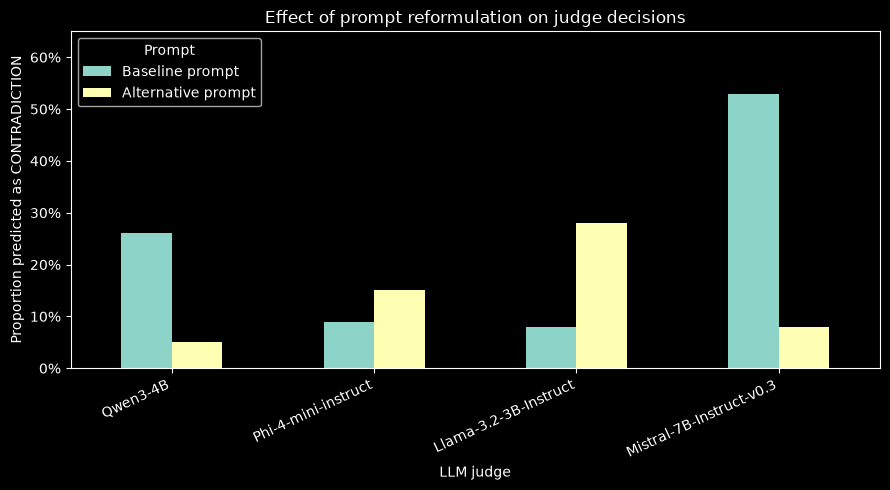

In [59]:
prompt_rate_plot = (
    prompt_robustness_summary[
        [
            "baseline_C_rate",
            "alternate_C_rate",
        ]
    ]
    .rename(
        columns={
            "baseline_C_rate":
                "Baseline prompt",
            "alternate_C_rate":
                "Alternative prompt",
        }
    )
)


ax = prompt_rate_plot.plot(
    kind="bar",
    figsize=(
        9,
        5,
    ),
)


ax.set_xlabel(
    "LLM judge"
)

ax.set_ylabel(
    "Proportion predicted as CONTRADICTION"
)

ax.set_title(
    "Effect of prompt reformulation on judge decisions"
)

ax.yaxis.set_major_formatter(
    PercentFormatter(
        xmax=1
    )
)

ax.set_ylim(
    0,
    0.65,
)

ax.legend(
    title="Prompt"
)

plt.xticks(
    rotation=25,
    ha="right",
)

plt.tight_layout()
plt.show()

Prompt robustness differs substantially across the four LLM judges.

Phi is the most stable under the tested reformulation: 94% of its decisions
remain unchanged (95% bootstrap CI [89%, 98%]), with Cohen's
\(\kappa=0.718\). Its overall contradiction rate changes only moderately,
from 9% to 15%.

Qwen and Llama show lower stability. Qwen agrees with its baseline decisions
on 79% of examples (95% CI [70%, 87%]), while its contradiction rate decreases
from 26% to 5%. All 21 changed Qwen decisions move from `CONTRADICTION` to
`NO_CONTRADICTION`.

Llama has 76% raw agreement (95% CI [66%, 86%]), but its contradiction rate
increases from 8% to 28%. Of its 24 changed decisions, 22 move from
`NO_CONTRADICTION` to `CONTRADICTION`.

Mistral is the least robust under this prompt reformulation. Only 53% of its
decisions remain unchanged (95% CI [42%, 63%]), and its contradiction rate
decreases from 53% to 8%. Of the 47 changed decisions, 46 move from
`CONTRADICTION` to `NO_CONTRADICTION`.

The changes are therefore not merely random label flips. The prompt
reformulation produces strong, model-specific shifts in contradiction
propensity. This indicates that conclusions based on a single LLM judge may
depend substantially on the exact formulation of the judging prompt.

These results concern one alternative prompt and a sample of 100 examples.
They should therefore be interpreted as evidence of prompt sensitivity under
the tested reformulation rather than as a general estimate of each model's
prompt robustness.

## 8. Discussion and limitations

### 8.1 Main findings

The results show that LLM-based persona contradiction judgments depend
substantially on the choice of judge.

The four models have markedly different contradiction tendencies. Across the
complete experiment, contradiction rates range from 12.2% for Llama to 55.5%
for Mistral. Pairwise raw agreement ranges from 54.6% to 85.4%, while Cohen's
kappa ranges from 0.162 to 0.379. The discrepancy between raw agreement and
kappa is particularly visible on original examples, where several judges
strongly prefer `NO_CONTRADICTION`.

The permutation analysis provides strong evidence that these differences are
systematic rather than compatible with the null model of exchangeable judge
identities. The largest difference between judge contradiction rates is
43.3 percentage points, and the permutation test gives \(p<0.001\).

The contradiction-oriented persona augmentation also produces a clear
directional response. The mean number of `CONTRADICTION` votes increases from
0.617 to 1.717 out of four judges, corresponding to a mean paired increase of

\[
1.100
\]

votes. The paired permutation test gives \(p<0.001\), and the 95% percentile
bootstrap confidence interval for the mean increase is

\[
[1.026,\ 1.172].
\]

The number of contradiction votes increases for 60.5% of dialogue pairs,
remains unchanged for 37.2%, and decreases for only 2.3%.

Not all investigated input characteristics show a detectable relationship
with judge behaviour. The estimated linear association between input length
and contradiction vote share is very weak
(\(r=-0.036\)), and the permutation test does not reject the null model
(\(p=0.257\)). This result concerns a linear trend and does not rule out more
complex relationships with input length.

The exploratory augmentation-type analysis suggests that contradiction
detection also depends on the kind of persona modification. Preference and
aspiration negations receive substantially higher contradiction vote shares
than favorite and profession replacements. These comparisons are descriptive,
however, because category sizes are unequal and several categories contain
only a small number of single-type examples.

Finally, the prompt-robustness experiment shows that stability under prompt
reformulation is strongly model-dependent. Phi preserves 94% of its decisions
under the tested reformulation, whereas Mistral preserves only 53%. Qwen and
Llama fall between these extremes. The direction of the changes is also
model-specific, showing that prompt wording can alter not only individual
predictions but also a model's overall tendency to predict contradictions.

Taken together, these results suggest that an LLM judge should not be treated
as a neutral or interchangeable measurement instrument. Both model choice and
prompt formulation can materially influence the resulting contradiction
judgments.

### 8.2 Limitations

Several limitations are important when interpreting the results.

First, the automatically derived expected relations in the augmented dataset
are not human-verified ground truth. They are used to construct the
experimental sample, but the main analyses concern agreement and judge
behaviour rather than classification accuracy. In particular, an original
PersonaChat profile is not guaranteed to be completely contradiction-free,
and an automatically augmented profile is not guaranteed to contain an
unambiguous contradiction.

Second, the experiment is restricted to rule-based augmented profiles with at
least one changed fact grounded in the dialogue. The results therefore
characterize this selected experimental sample and should not automatically be
generalized to all PersonaChat dialogues or to arbitrary persona-consistency
datasets.

Third, the four judges are relatively small open language models from four
model families. Larger proprietary models or other open models may exhibit
different contradiction thresholds and different levels of agreement.

Fourth, the augmentation-type analysis is exploratory. Only 702 of the 1,000
augmented profiles contain a single unique augmentation type, and the category
sizes are highly unequal. Results for the smallest categories are therefore
especially uncertain.

Fifth, the input-length analysis tests a linear trend. Failure to reject the
null model should not be interpreted as evidence that input length has no
relationship of any kind with judge behaviour.

Finally, prompt robustness is evaluated using only one alternative prompt on
50 dialogue pairs. The observed sensitivity demonstrates that wording can
matter, but it is not a general estimate of each model's robustness to all
possible prompt formulations.

For these reasons, the study is best interpreted as an analysis of the
reliability and variability of LLM judges under a controlled experimental
setup, rather than as an evaluation against a definitive ground-truth
contradiction annotation.

## 9. Conclusion

This project investigated whether different LLM judges agree when detecting
persona contradictions in dialogue.

The results show that judge choice matters substantially. The four evaluated
models have different contradiction propensities and only limited
chance-corrected agreement. A permutation test provides strong evidence that
the observed differences between judge contradiction rates are systematic.

Contradiction-oriented persona augmentation produces a clear directional
change in the judgments. On average, the augmented persona receives
1.10 additional `CONTRADICTION` votes out of four judges, with a 95% bootstrap
confidence interval of [1.03, 1.17]. This effect is highly significant in the
paired permutation analysis.

The secondary analyses provide a more nuanced picture. No statistically
detectable linear relationship is found between input length and contradiction
vote share, while exploratory results indicate substantial differences across
augmentation categories. Prompt robustness also varies strongly by model:
some judges remain relatively stable under a reformulated prompt, whereas
others change a large fraction of their decisions.

Overall, the experiment shows that LLM-based contradiction judgments are not
fully interchangeable across models or prompts. When LLM judges are used for
persona-consistency evaluation, agreement between judges and sensitivity to
the evaluation setup should therefore be considered alongside the judgments
themselves.